<a href="https://colab.research.google.com/github/HelalaAShehri/Brain-Tumor-MRI-Explainable-CNN/blob/main/Brain_Tumor_MRI_GradCAM_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor MRI Classification with Grad-CAM Visualization
# Pretrained Model Demo for Inference and Explainability

This notebook demonstrates:

* loading the pretrained brain tumor classification model
* running inference on grayscale MRI images

* generating Grad-CAM visualizations

* constraining Grad-CAM to the anatomical brain region

* optionally visualizing attention across multiple convolutional layers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# Brain Tumor MRI Classification + Grad-CAM Demo
# Colab-ready inference notebook
# ============================================================

import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# Download pretrained model
!pip install gdown -q

import gdown

url = "https://drive.google.com/uc?id=1B9bfeIz6B3rUxW2LJg7Ze850_wde8ade"
output = "FinalModelBrain.keras"

gdown.download(url, output, quiet=False)

In [ ]:
#!gdown https://drive.google.com/uc?id=1B9bfeIz6B3rUxW2LJg7Ze850_wde8ade

Downloading...
From (original): https://drive.google.com/uc?id=1B9bfeIz6B3rUxW2LJg7Ze850_wde8ade
From (redirected): https://drive.google.com/uc?id=1B9bfeIz6B3rUxW2LJg7Ze850_wde8ade&confirm=t&uuid=f26365dd-5add-473e-b60a-2c4199d2d187
To: /content/FinalModelBrain.keras
100% 64.6M/64.6M [00:01<00:00, 38.7MB/s]


In [ ]:
# ============================================================
# CONFIG
# ============================================================

#MODEL_PATH = '/content/drive/MyDrive/FinalModelBrain.keras'# if you use gdown, no need for the file full path
MODEL_PATH = 'FinalModelBrain.keras'

IMG_SIZE = (125, 125)
CLASS_NAMES = ['notumor', 'pituitary', 'meningioma', 'glioma']

# Main Grad-CAM layer
LAST_CONV_LAYER = 'conv2d_13'

# Optional: for layer-wise Grad-CAM visualization
LAYER_LIST = ['conv2d_1', 'conv2d_3', 'conv2d_6', 'conv2d_9', 'conv2d_13']

# Brain-mask threshold
BRAIN_MASK_THRESHOLD = 0.05

print("Configuration loaded.")

Configuration loaded.


In [ ]:
# ============================================================
# LOAD MODEL
# ============================================================

model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model loaded successfully from:", MODEL_PATH)

✅ Model loaded successfully from: FinalModelBrain.keras


In [ ]:
model.summary()

Model: "GradCAM_Friendly_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 125, 125, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 125, 125, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 125, 125, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 125, 125, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 62, 62, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 62, 62, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 31, 31, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_5 (BatchNormalization)       │ (None, 31, 31, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 31, 31, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_6 (BatchNormalization)       │ (None, 31, 31, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 31, 31, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_7 (BatchNormalization)       │ (None, 31, 31, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 15, 15, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_8 (BatchNormalization)       │ (None, 15, 15, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 15, 15, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_9 (BatchNormalization)       │ (None, 15, 15, 256)    │         1,02

 Total params: 16,093,454 (61.39 MB)

 Trainable params: 5,362,692 (20.46 MB)

 Non-trainable params: 5,376 (21.00 KB)

 Optimizer params: 10,725,386 (40.91 MB)

In [ ]:

# ============================================================
# IMAGE PREPROCESSING
# ============================================================

def preprocess_image(img_path, target_size=IMG_SIZE):
    """
    Load grayscale MRI image and prepare it exactly as in training.

    Returns:
        img_array: (H, W, 1), float32 in [0,1]
        input_img: (1, H, W, 1), float32 in [0,1]
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Could not read image: {img_path}")

    # Match training resize exactly
    img = cv2.resize(img, target_size)

    # Match training shape and normalization
    img_array = img.astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=-1)   # (H, W, 1)
    input_img = np.expand_dims(img_array, axis=0)    # (1, H, W, 1)

    return img_array, input_img

def build_brain_mask(img01, thr=BRAIN_MASK_THRESHOLD):
    """
    Create a simple binary brain mask from normalized grayscale MRI.

    img01: (H, W, 1), values in [0,1]
    """
    gray = img01.squeeze().astype(np.float32)
    mask = (gray > thr).astype(np.float32)
    return mask

In [ ]:
# ============================================================
# GRAD-CAM WITH BRAIN MASK
# ============================================================

def get_gradcam_heatmap(model, image_array, class_index, last_conv_layer_name):
    """
    Generate Grad-CAM heatmap for a given image and class,
    then constrain the heatmap to the brain region.

    image_array: shape (1, H, W, 1)
    """
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_array, training=False)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)[0]     # (h, w, c)
    conv_outputs = conv_outputs[0]                   # (h, w, c)

    weights = tf.reduce_mean(grads, axis=(0, 1))    # (c,)
    cam = np.zeros(conv_outputs.shape[:2], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * conv_outputs[:, :, i]

    cam = np.maximum(cam, 0)
    cam = cam / cam.max() if cam.max() != 0 else cam

    # ---------------------------
    # Brain mask at original size
    # ---------------------------
    original_image_gray = image_array[0].squeeze()
    full_res_brain_mask = (original_image_gray > BRAIN_MASK_THRESHOLD).astype(np.float32)

    # Resize brain mask to heatmap size
    heatmap_h, heatmap_w = cam.shape
    resized_brain_mask = cv2.resize(
        full_res_brain_mask, (heatmap_w, heatmap_h), interpolation=cv2.INTER_LINEAR
    )
    resized_brain_mask = (resized_brain_mask > 0.5).astype(np.float32)

    # Apply brain mask
    cam = cam * resized_brain_mask

    return cam

In [ ]:
# ============================================================
# OVERLAY + VISUALIZATION
# ============================================================

def overlay_heatmap_on_image(img_array, heatmap, alpha=0.4, colormap=cv2.COLORMAP_TURBO):
    """
    Overlay heatmap on grayscale MRI image.

    img_array: (H, W, 1), normalized [0,1]
    heatmap:   (h, w), normalized [0,1]
    """
    gray = img_array.squeeze()
    rgb = cv2.cvtColor(np.uint8(gray * 255), cv2.COLOR_GRAY2BGR)

    heatmap_resized = cv2.resize(heatmap, (rgb.shape[1], rgb.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), colormap)

    overlay = cv2.addWeighted(rgb, 0.6, heatmap_colored, alpha, 0)
    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    return overlay_rgb, heatmap_resized


def print_prediction_table(prediction, class_names=CLASS_NAMES):
    print("Prediction probabilities:")
    for i, cls in enumerate(class_names):
        print(f"{cls:12s}: {prediction[i]:.6f}")

In [ ]:
# ============================================================
# SINGLE IMAGE PREDICTION
# ============================================================

def predict_image(model, img_path, class_names=CLASS_NAMES):
    """
    Run inference on one MRI image.
    """
    img_array, input_img = preprocess_image(img_path)

    prediction = model.predict(input_img, verbose=0)[0]
    pred_idx = int(np.argmax(prediction))
    pred_class = class_names[pred_idx]
    confidence = float(prediction[pred_idx])

    return img_array, input_img, prediction, pred_idx, pred_class, confidence

In [ ]:
# ============================================================
# SHOW PREDICTION + GRAD-CAM
# ============================================================

def show_prediction_with_gradcam(
    model,
    img_path,
    conv_layer=LAST_CONV_LAYER,
    class_names=CLASS_NAMES,
    true_label=None
):
    img_array, input_img, prediction, pred_idx, pred_class, confidence = predict_image(
        model, img_path, class_names
    )

    heatmap = get_gradcam_heatmap(model, input_img, pred_idx, conv_layer)
    overlay_rgb, heatmap_resized = overlay_heatmap_on_image(img_array, heatmap, alpha=0.4)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_array.squeeze(), cmap='gray')
    axes[0].set_title("Original MRI", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(heatmap_resized, cmap='turbo')
    axes[1].set_title("Grad-CAM Heatmap", fontsize=12, fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(overlay_rgb)
    title = f"Pred: {pred_class} ({confidence:.2%})"
    if true_label is not None:
        title += f"\nTrue: {true_label}"
    axes[2].set_title(title, fontsize=12, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    print_prediction_table(prediction, class_names)




# ============================================================
# SHOW PREDICTION + OVERLAY (2 columns only)
# ============================================================

def show_prediction_with_overlay(
    model,
    img_path,
    conv_layer=LAST_CONV_LAYER,
    class_names=CLASS_NAMES,
    true_label=None
):
    img_array, input_img, prediction, pred_idx, pred_class, confidence = predict_image(
        model, img_path, class_names
    )

    heatmap = get_gradcam_heatmap(model, input_img, pred_idx, conv_layer)
    overlay_rgb, _ = overlay_heatmap_on_image(img_array, heatmap, alpha=0.4)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # ------------------------------------------------
    # Column 1: Original MRI
    # ------------------------------------------------
    axes[0].imshow(img_array.squeeze(), cmap='gray')
    axes[0].set_title("Original MRI", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # ------------------------------------------------
    # Column 2: Original MRI + Grad-CAM overlay
    # ------------------------------------------------
    axes[1].imshow(overlay_rgb)

    title = f"Pred: {pred_class} ({confidence:.2%})"
    if true_label is not None:
        title += f"\nTrue: {true_label}"

    axes[1].set_title(title, fontsize=12, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    print_prediction_table(prediction, class_names)

In [ ]:
# ============================================================
# LAYER-WISE GRAD-CAM (Figure 9 style)
# ============================================================

def show_layerwise_gradcam(
    model,
    img_path,
    conv_layers=LAYER_LIST,
    class_names=CLASS_NAMES
):
    img_array, input_img, prediction, pred_idx, pred_class, confidence = predict_image(
        model, img_path, class_names
    )

    original_rgb = cv2.cvtColor(np.uint8(img_array.squeeze() * 255), cv2.COLOR_GRAY2RGB)

    images = [original_rgb]
    titles = ["Original MRI"]

    for layer in conv_layers:
        heatmap = get_gradcam_heatmap(model, input_img, pred_idx, layer)
        overlay_rgb, _ = overlay_heatmap_on_image(img_array, heatmap, alpha=0.4)
        images.append(overlay_rgb)
        titles.append(layer)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < len(images):
            ax.imshow(images[i], cmap='gray' if i == 0 else None)
            ax.set_title(titles[i], fontsize=11)
            ax.axis('off')
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Predicted class: {pred_class} ({confidence:.2%})")
    print_prediction_table(prediction, class_names)

In [ ]:
# ============================================================
# RUN DEMO ON A FOLDER OF SAMPLE IMAGES
# ============================================================

def run_demo_on_folder(
    model,
    folder_path,
    conv_layer=LAST_CONV_LAYER,
    class_names=CLASS_NAMES,
    max_images=4
):
    valid_ext = ('.png', '.jpg', '.jpeg', '.bmp')
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_ext)]
    image_files = sorted(image_files)[:max_images]

    if len(image_files) == 0:
        print("⚠️ No image files found in:", folder_path)
        return

    for fname in image_files:
        print("=" * 80)
        print("Image:", fname)
        show_prediction_with_overlay(
            model=model,
            img_path=os.path.join(folder_path, fname),
            conv_layer=conv_layer,
            class_names=class_names
        )

##Example usage

### A) Single image

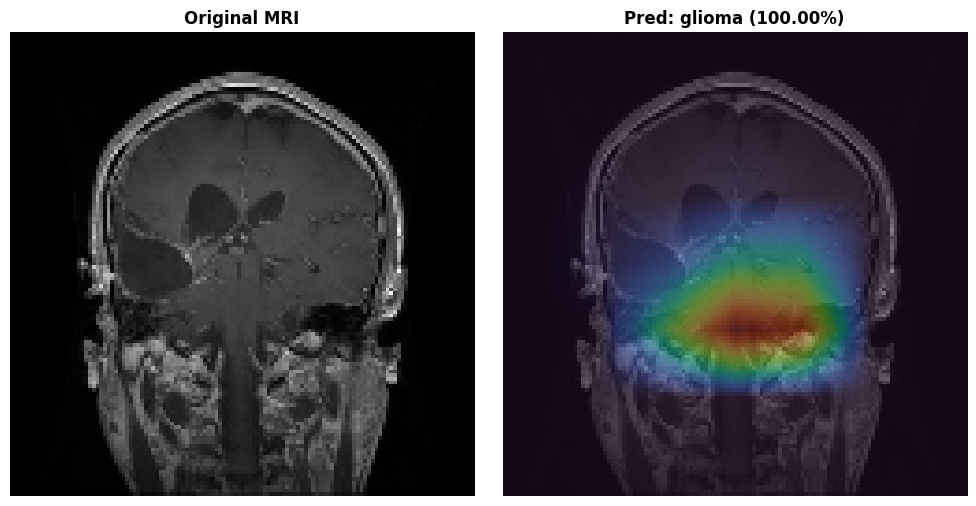

Prediction probabilities:
notumor     : 0.000000
pituitary   : 0.000000
meningioma  : 0.000000
glioma      : 1.000000


In [ ]:
IMG_PATH = '../sample_images/glioma_01.jpg'
show_prediction_with_overlay(model, IMG_PATH, conv_layer=LAST_CONV_LAYER)

###B) Layer-wise Grad-CAM

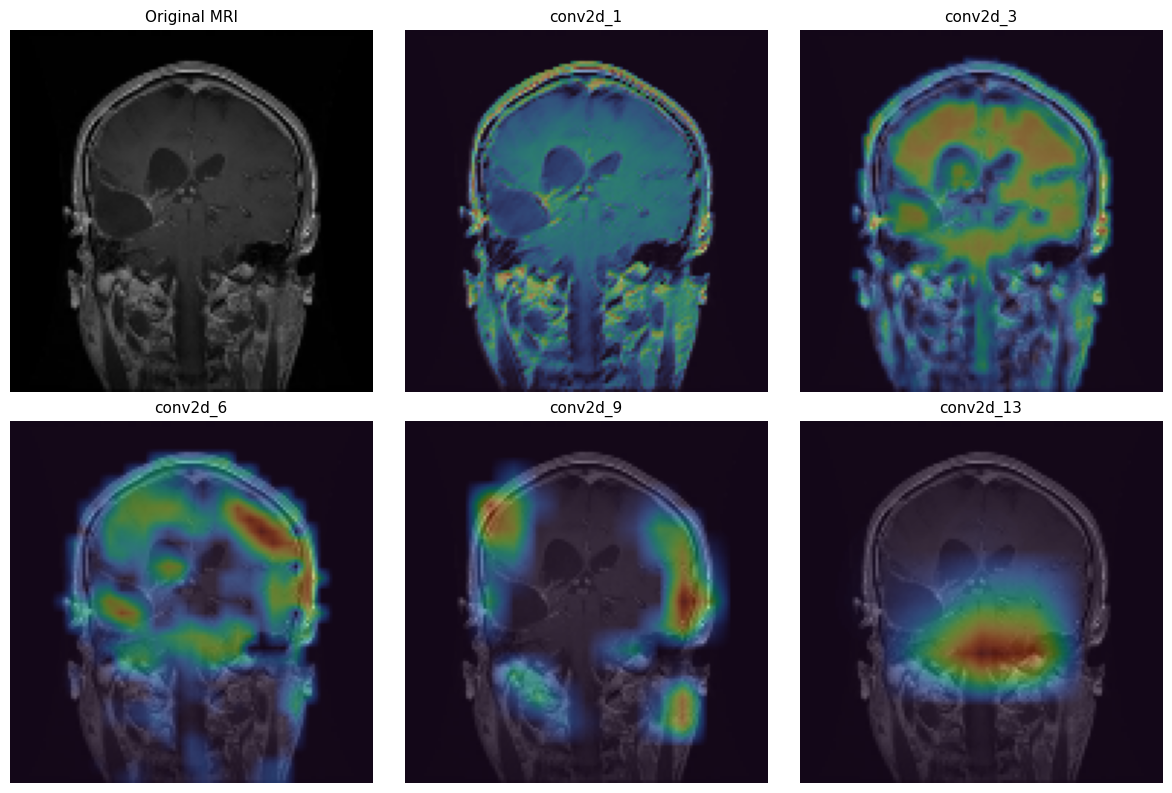

Predicted class: glioma (100.00%)
Prediction probabilities:
notumor     : 0.000000
pituitary   : 0.000000
meningioma  : 0.000000
glioma      : 1.000000


In [ ]:

IMG_PATH = '../sample_images/glioma_01.jpg'
show_layerwise_gradcam(model, IMG_PATH, conv_layers=LAYER_LIST)

C) Run demo on a sample folder

Image: Tr-gl_1253.jpg


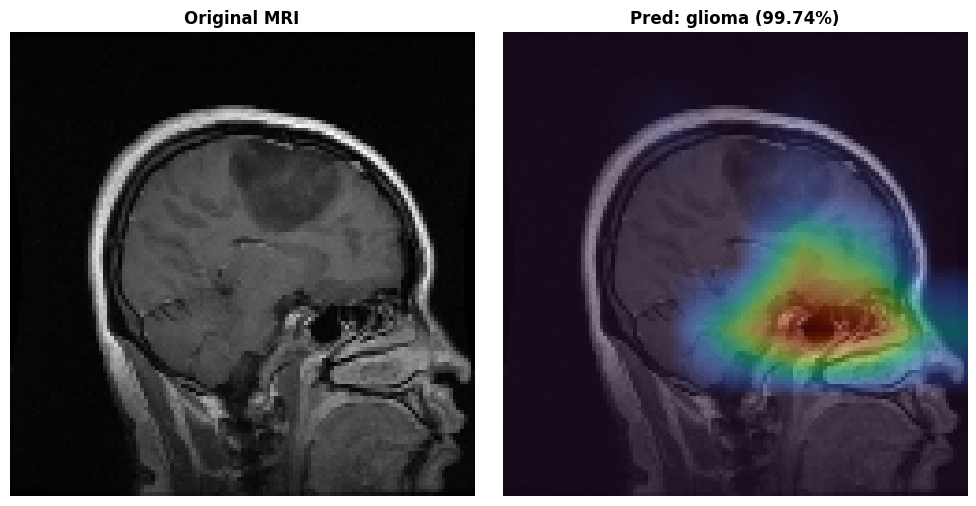

Prediction probabilities:
notumor     : 0.000163
pituitary   : 0.000203
meningioma  : 0.002283
glioma      : 0.997351
Image: Tr-pi_1396.jpg


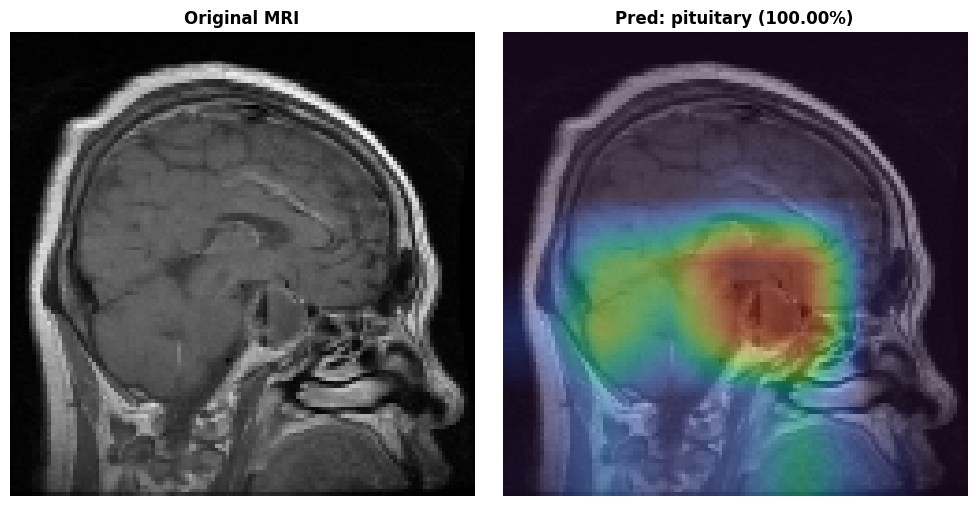

Prediction probabilities:
notumor     : 0.000000
pituitary   : 1.000000
meningioma  : 0.000000
glioma      : 0.000000
Image: glioma_01.jpg


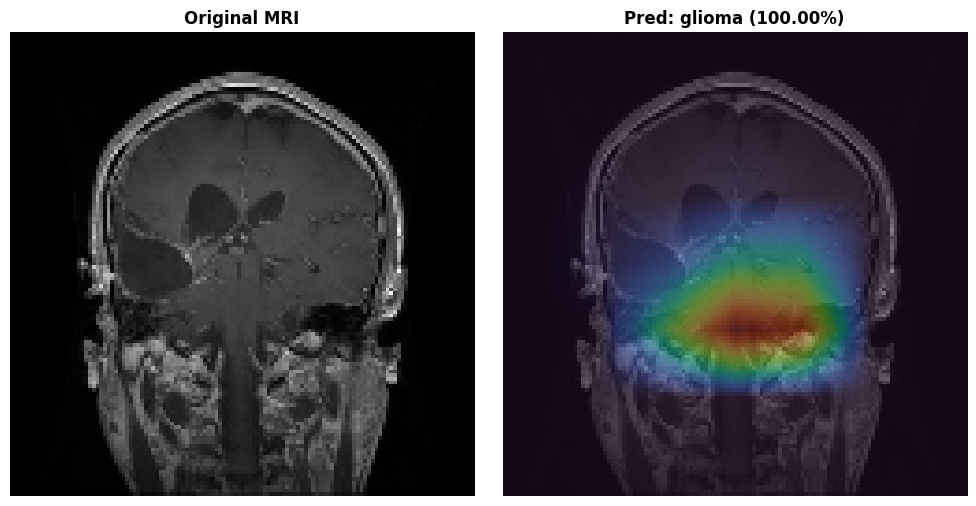

Prediction probabilities:
notumor     : 0.000000
pituitary   : 0.000000
meningioma  : 0.000000
glioma      : 1.000000
Image: glioma_02.jpg


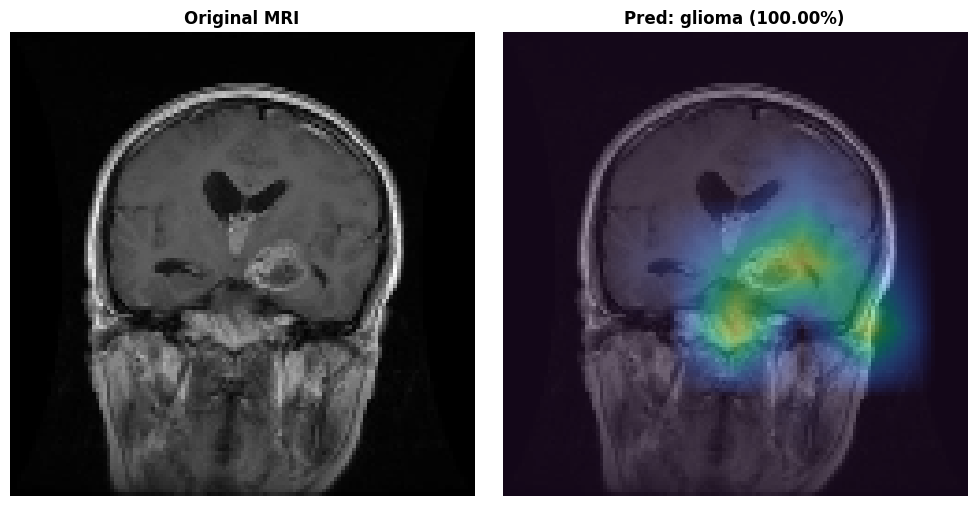

Prediction probabilities:
notumor     : 0.000000
pituitary   : 0.000000
meningioma  : 0.000004
glioma      : 0.999996


In [ ]:
DEMO_FOLDER = '../sample_images/'
run_demo_on_folder(model, DEMO_FOLDER, conv_layer=LAST_CONV_LAYER, max_images=4)

## Optional: upload-from-Colab cell

Saving Tr-me_1300.jpg to Tr-me_1300 (1).jpg


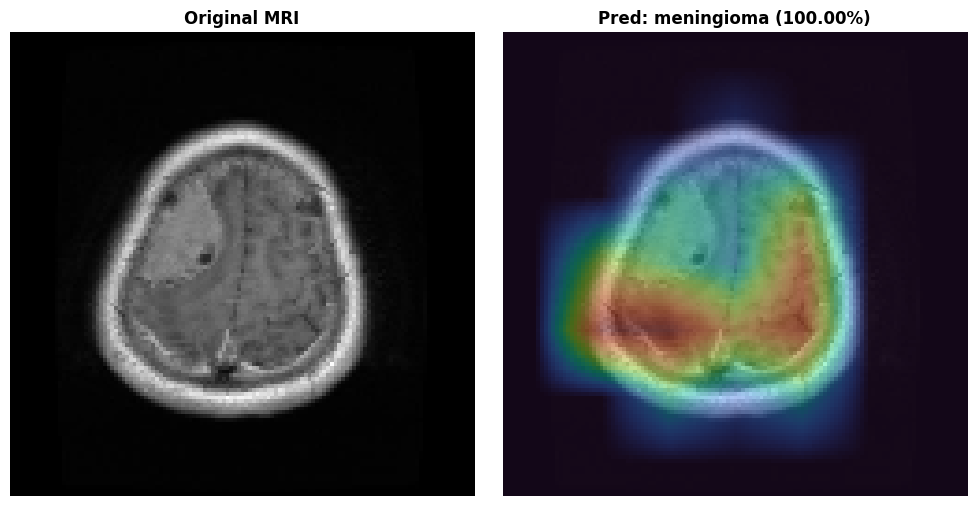

Prediction probabilities:
notumor     : 0.000000
pituitary   : 0.000011
meningioma  : 0.999984
glioma      : 0.000005


In [ ]:
from google.colab import files

uploaded = files.upload()
uploaded_file = list(uploaded.keys())[0]

show_prediction_with_overlay(model, uploaded_file, conv_layer=LAST_CONV_LAYER)